# Dataset loading and synchronisation example

In this example we will analyse data from a toy experiment where a user must speed-type based on a series of word prompts.

Note that all timestamping here comes from Bonsai timestamps, therefore some of the reported jitters are higher than in the case of using hardware timestamping.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import swc.aeon.io.api as aeon
from dotmap import DotMap
from swc.aeon.io.video import frames
from swc.aeon.schema.streams import Device

from ucl_open.io.streams import csv, raw_video
from ucl_open.io.sync import synchronise_to

## Define the experiment

Specify a root folder and data mapping

In [46]:
root = Path(r"C:\temp_data\sub-Andrew\ses-001_date-2026-10-05T14-41-31")

experiment = DotMap(
    [
        Device("Video", raw_video()),
        Device("TrialResult", csv(columns=("subject", "target"))),
        Device("KeyInput", csv(columns=["key"])),
        Device("CurrentWord", csv(columns=["current_word"])),
        Device("AsyncPulse", csv(columns=["pulse"])),
    ]
)

print(experiment.keys())

odict_keys(['Video', 'TrialResult', 'KeyInput', 'CurrentWord', 'AsyncPulse'])


## Load the dataset

In [47]:
video = aeon.load(root, experiment.Video)
trial_result = aeon.load(root, experiment.TrialResult)  
key_input = aeon.load(root, experiment.KeyInput)
current_word = aeon.load(root, experiment.CurrentWord)
async_pulse = aeon.load(root, experiment.AsyncPulse)
video.head()

,width,height,_frame,_path,_epoch
time,,,,,
1904-01-01 00:00:00.297000+00:00,640,480,0,C:\temp_data\sub-Andrew\ses-001_date-2026-10-0...,ses-001_date-2026-10-05T14-41-31
1904-01-01 00:00:00.319000+00:00,640,480,1,C:\temp_data\sub-Andrew\ses-001_date-2026-10-0...,ses-001_date-2026-10-05T14-41-31
1904-01-01 00:00:00.341000+00:00,640,480,2,C:\temp_data\sub-Andrew\ses-001_date-2026-10-0...,ses-001_date-2026-10-05T14-41-31
1904-01-01 00:00:00.363000+00:00,640,480,3,C:\temp_data\sub-Andrew\ses-001_date-2026-10-0...,ses-001_date-2026-10-05T14-41-31
1904-01-01 00:00:00.385000+00:00,640,480,4,C:\temp_data\sub-Andrew\ses-001_date-2026-10-0...,ses-001_date-2026-10-05T14-41-31


## Synchronisation check

This dataset has been deliberately collected with two separate timebases with slightly drifting clocks. User input and trial events (key presses, word generation etc.) are on one clock; and video data is collected on a different clock. We have added an example async pulse link in which a sample from the video data clock is periodically sent to a device on the user input clock. These samples are logged under `AsyncPulse`, where the time index is the user index clock and the value is the corresponding time from the video data clock.

We can observe the synchronisation problem by inspecting video frames where the `Enter` key is pressed. 

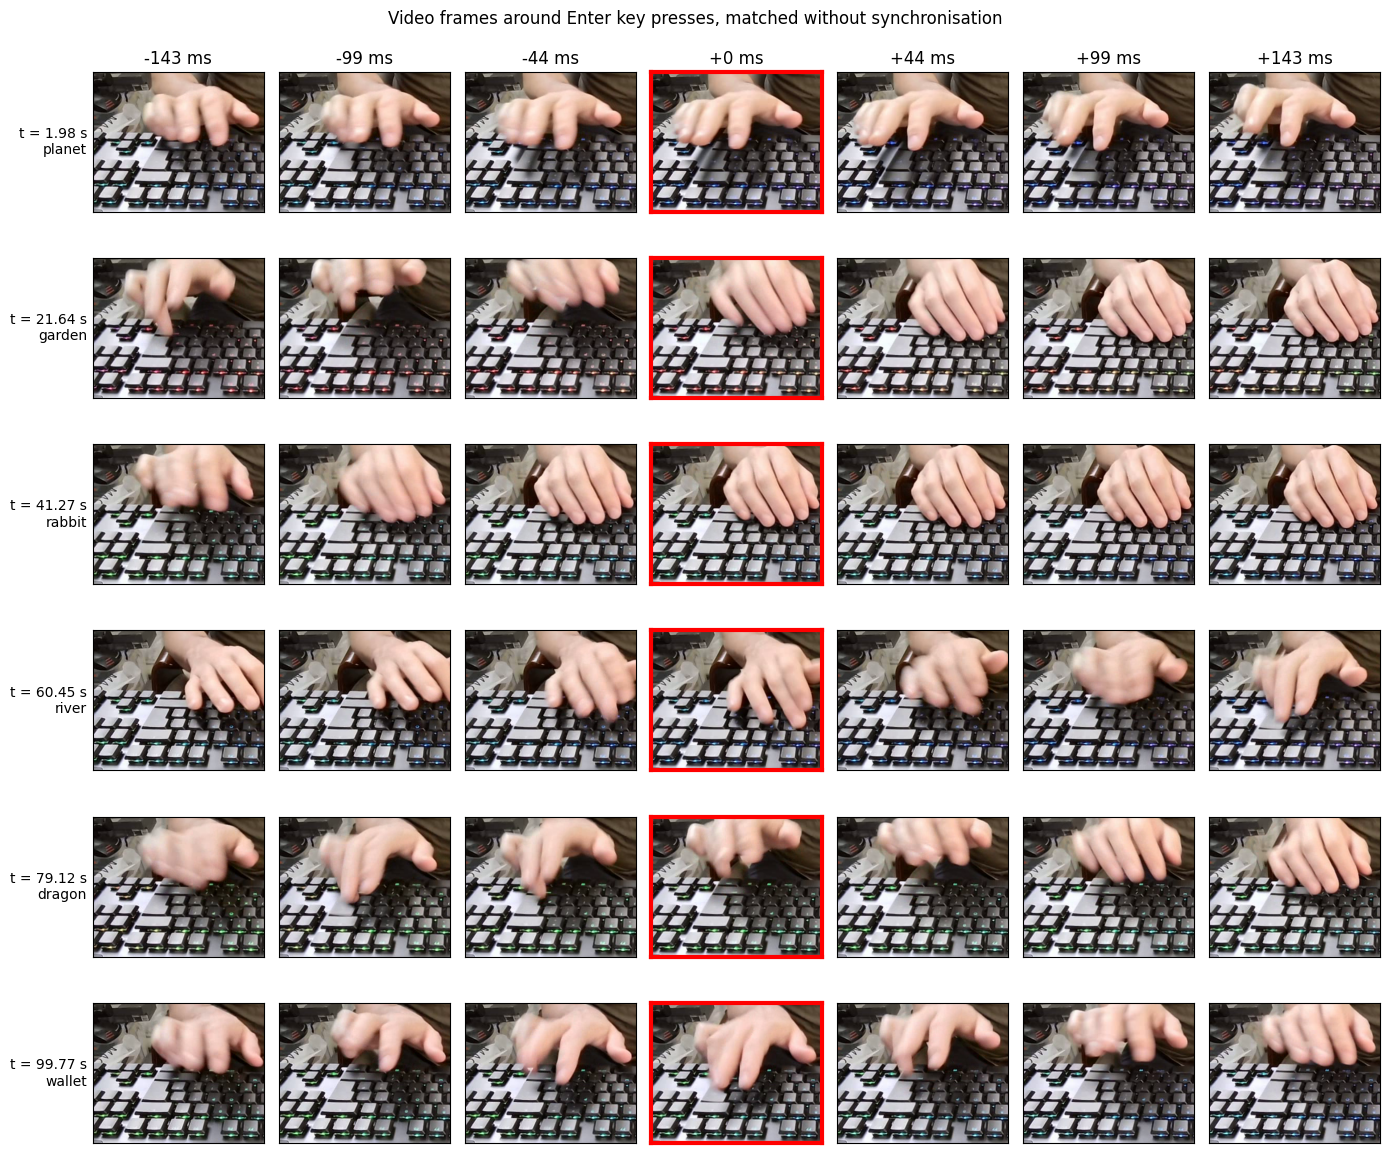

In [48]:
# Select Enter key presses spread evenly across the session (Enter is logged as "Return")
enter_presses = key_input[key_input.key == "Return"]
examples = enter_presses.iloc[np.linspace(0, len(enter_presses) - 1, 6).astype(int)]
targets = trial_result.target.reindex(examples.index, method="nearest")

# Frames either side of the matched frame, and the image region around the Enter key
frame_offsets = np.arange(-6, 7, 2)
enter_region = (slice(60, 330), slice(0, 330))


def plot_key_presses(video, frame_indices, title, labels):
    """Plots a strip of video frames around each matched frame, one row per key press."""
    fig, axes = plt.subplots(len(frame_indices), len(frame_offsets), figsize=(14, 2 * len(frame_indices)))
    for row, (center, label) in enumerate(zip(frame_indices, labels)):
        indices = np.clip(center + frame_offsets, 0, len(video) - 1)
        for col, (index, image) in enumerate(zip(indices, frames(video.iloc[indices]))):
            ax = axes[row, col]
            ax.imshow(image[enter_region][:, :, ::-1])
            ax.set_xticks([])
            ax.set_yticks([])
            if index == center:
                for spine in ax.spines.values():
                    spine.set_color("red")
                    spine.set_linewidth(3)
            if row == 0:
                offset_ms = (video.index[index] - video.index[center]).total_seconds() * 1000
                ax.set_title(f"{offset_ms:+.0f} ms")
        axes[row, 0].set_ylabel(label, rotation=0, ha="right", va="center")
    fig.suptitle(title)
    plt.tight_layout()


# Naively match each key press to the nearest video frame, ignoring that the clocks differ
frame_indices = video.index.get_indexer(examples.index, method="nearest")
labels = [f"t = {aeon.to_seconds(time):.2f} s\n{target}" for time, target in targets.items()]
plot_key_presses(video, frame_indices, "Video frames around Enter key presses, matched without synchronisation", labels)

## Synchronisation correction

`synchronise_to` fits a linear mapping between the two clocks from the `AsyncPulse` samples, and remaps the video
time index onto the user input clock. Each pulse gives the video clock time (`pulse`) at a known user input clock
time (the index), so the video data is mapped from the `pulse` clock to the index clock.

With the video on the same clock as the key presses, the frames at each `Enter` key press can be matched directly.
The matched frame for each key press is outlined in red, and the label shows how far it is from the frame matched
without synchronisation, in seconds of video.

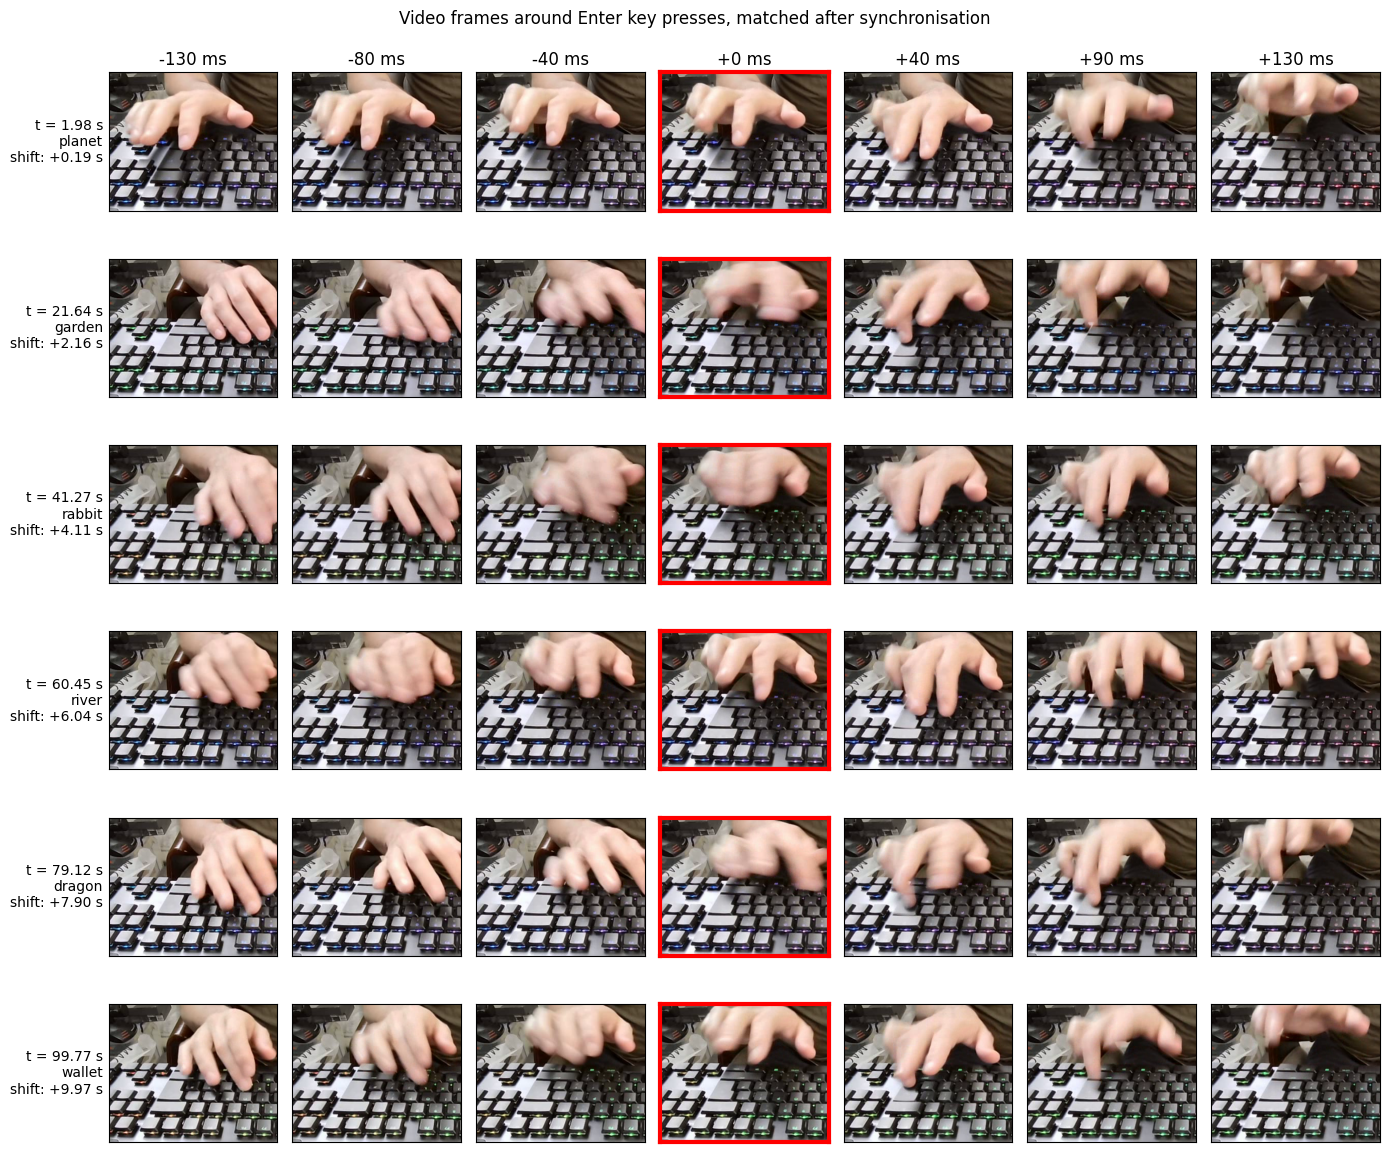

In [49]:
video_synced = synchronise_to(video, from_clock=async_pulse.pulse, to_clock=async_pulse.index)

# Match each key press to the nearest video frame, now that both are on the user input clock
synced_indices = video_synced.index.get_indexer(examples.index, method="nearest")

# Shift between the corrected and uncorrected frames, in seconds of video
shifts = (video.index[synced_indices] - video.index[frame_indices]).total_seconds()
labels = [
    f"t = {aeon.to_seconds(time):.2f} s\n{target}\nshift: {shift:+.2f} s"
    for (time, target), shift in zip(targets.items(), shifts)
]
plot_key_presses(
    video_synced, synced_indices, "Video frames around Enter key presses, matched after synchronisation", labels
)

With the synchronised video, we could reconfirm by extracting all the frames corresponding to another particular key

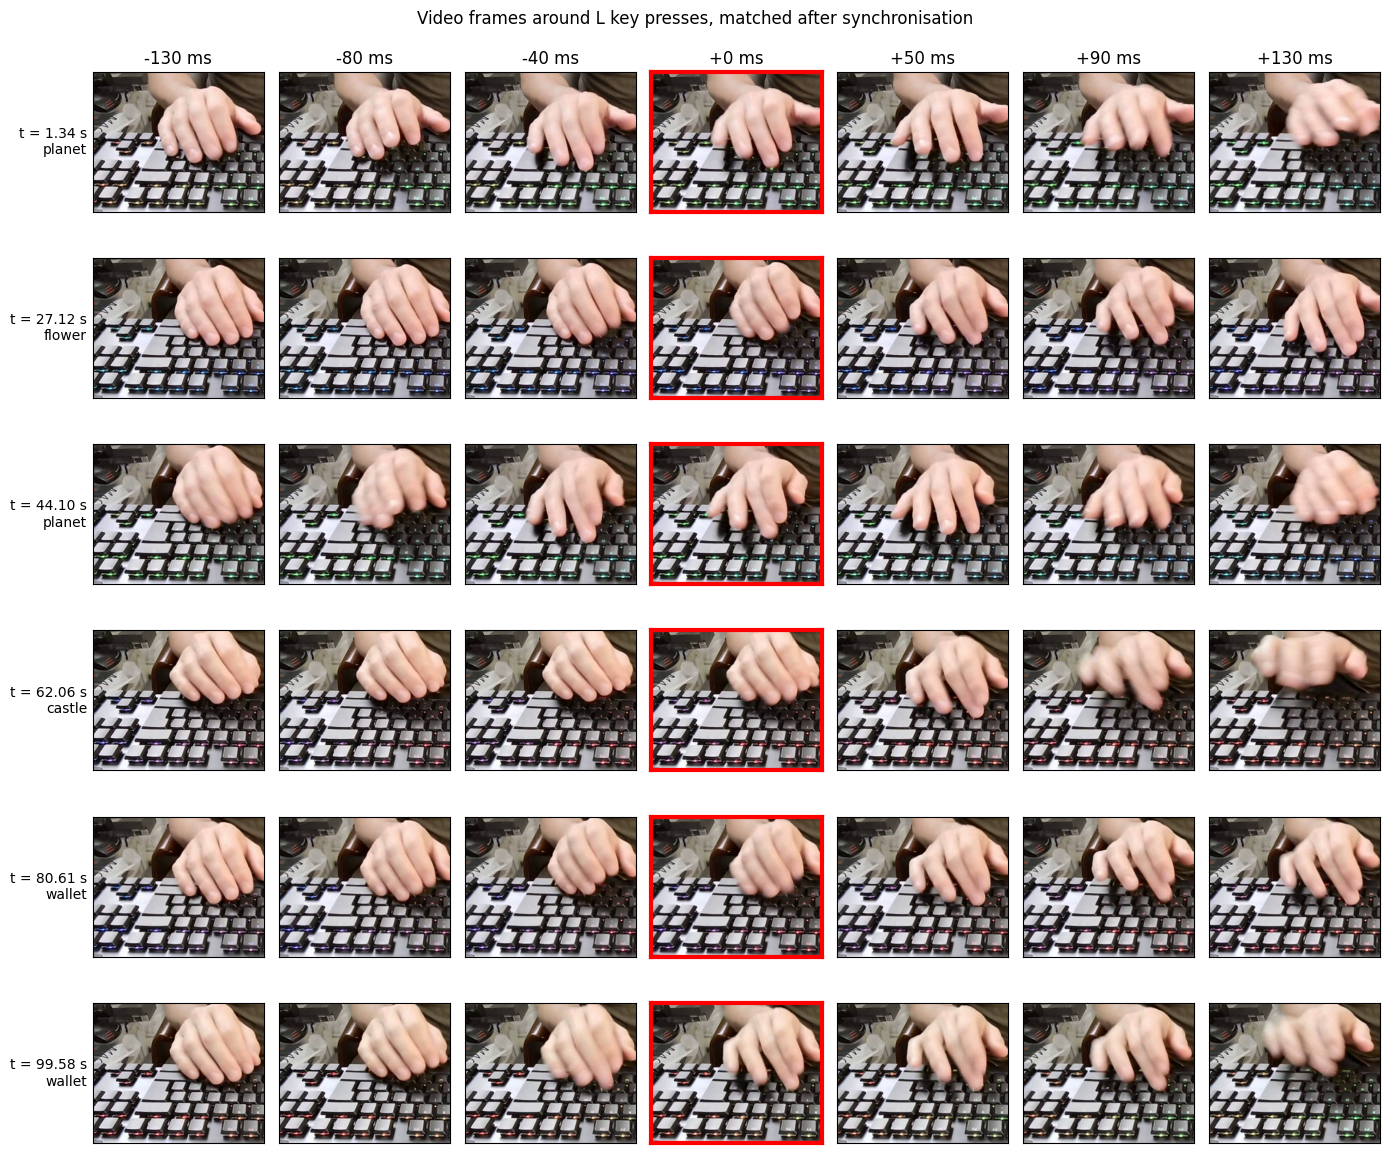

In [50]:
l_presses = key_input[key_input.key == "L"]
examples = l_presses.iloc[np.linspace(0, len(l_presses) - 1, 6).astype(int)]
targets = trial_result.target.reindex(examples.index, method="nearest")

frame_indices = video_synced.index.get_indexer(examples.index, method="nearest")
labels = [f"t = {aeon.to_seconds(time):.2f} s\n{target}" for time, target in targets.items()]
plot_key_presses(video_synced, frame_indices, "Video frames around L key presses, matched after synchronisation", labels)

We can also check the mapping by running `synchronise_to` on the sync source itself. The time index of `data` must be
on the same clock as `from_clock`. `async_pulse` is indexed on the user input clock, so the index is `from_clock`
and the video clock (`pulse`) is `to_clock`. After synchronisation, the index should match the `pulse` values, up to
the error of the linear fit.

In [51]:
synced_pulse = synchronise_to(async_pulse, from_clock=async_pulse.index, to_clock=async_pulse.pulse)

fit_error = aeon.to_seconds(synced_pulse.index) - synced_pulse.pulse.values
print(f"Maximum fit error: {abs(fit_error).max() * 1000:.1f} ms")
synced_pulse.assign(synced_index=aeon.to_seconds(synced_pulse.index)).head()

Maximum fit error: 9.5 ms


,pulse,synced_index
time,,
1904-01-01 00:00:02.447832199+00:00,2.453,2.447832
1904-01-01 00:00:04.548905970+00:00,4.543,4.548906
1904-01-01 00:00:08.388040768+00:00,8.393,8.388041
1904-01-01 00:00:11.677156253+00:00,11.682,11.677156
1904-01-01 00:00:13.921235046+00:00,13.915,13.921235
